In [2]:
 # ============================================================
# CELL 1: SETUP — Imports & Drive Mount
# ============================================================
!pip install rasterio scikit-learn geopandas --quiet

import rasterio
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy import ndimage
from scipy.ndimage import median_filter, label  # for spatial post-processing (median filter + connected components)
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import warnings
warnings.filterwarnings('ignore')  # GMM/sklearn convergence warnings can get noisy across many K values

from google.colab import drive
drive.mount('/content/drive')

print("✅ Imports & Drive ready")

Mounted at /content/drive
✅ Imports & Drive ready


In [ ]:
 #============================================================
# CELL 2: Load & Reshape PCA TIF
# ============================================================
tif_path = '/content/drive/MyDrive/GEE_Exports/Varanasi_PCA_8bands_Kharif_2025.tif'

with rasterio.open(tif_path) as src:
    pca_img = src.read()
    profile = src.profile
    transform = src.transform
    crs = src.crs

n_bands, height, width = pca_img.shape
print(f"Loaded: {n_bands} components, {height}x{width} pixels")

# Reshape to (n_pixels, n_components)
X_full = pca_img.reshape(n_bands, -1).T
print(f"Reshaped: {X_full.shape}")

# Valid pixels only (no NaN)
valid_mask = ~np.isnan(X_full).any(axis=1)
X_valid = X_full[valid_mask]
print(f"Valid pixels: {X_valid.shape[0]} / {X_full.shape[0]} ({100*X_valid.shape[0]/X_full.shape[0]:.1f}%)")

# Clear memory
del pca_img
print("✅ Data loaded")

Loaded: 8 components, 2330x2669 pixels
Reshaped: (6218770, 8)
Valid pixels: 3326058 / 6218770 (53.5%)
✅ Data loaded


In [ ]:
# ============================================================
# CELL 3: Normalize PCA Components
# ============================================================
scaler = StandardScaler()
X_pca_norm = scaler.fit_transform(X_valid)
print(f"Normalized shape: {X_pca_norm.shape}")
print(f"Mean (should be ~0): {X_pca_norm.mean(axis=0)[:3]}")
print(f"Std (should be ~1): {X_pca_norm.std(axis=0)[:3]}")
print("✅ Normalization complete")

Normalized shape: (3326058, 8)
Mean (should be ~0): [-3.31286483e-15 -1.02793729e-14  6.83593720e-17]
Std (should be ~1): [1. 1. 1.]
✅ Normalization complete


Testing K on 50000 pixels...

K=3: BIC=1061388, Silhouette=0.094, DB=2.706
K=4: BIC=1057167, Silhouette=0.062, DB=2.580
K=5: BIC=1055721, Silhouette=0.076, DB=2.309
K=6: BIC=1054698, Silhouette=0.078, DB=2.221
K=7: BIC=1054290, Silhouette=0.072, DB=2.246
K=8: BIC=1053394, Silhouette=0.068, DB=2.226
K=9: BIC=1053861, Silhouette=0.059, DB=2.108

✅ Optimal K: 6

   K           BIC  Silhouette  Davies-Bouldin
0  3  1.061388e+06    0.094040        2.705871
1  4  1.057167e+06    0.062442        2.579932
2  5  1.055721e+06    0.076339        2.309385
3  6  1.054698e+06    0.078351        2.221208
4  7  1.054290e+06    0.071560        2.246316
5  8  1.053394e+06    0.067516        2.226488
6  9  1.053861e+06    0.058503        2.107574


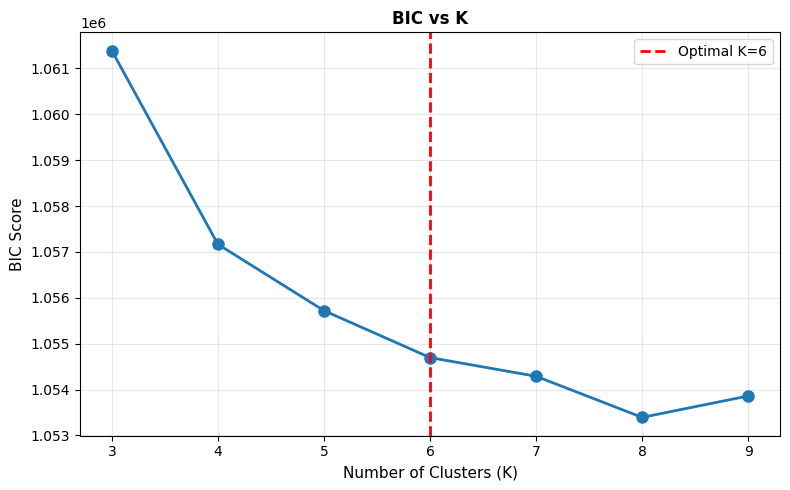

✅ BIC search complete


In [ ]:
# ============================================================
# CELL 4: Find Optimal K via BIC
# ============================================================
# Subsample for speed
sample_size = min(50000, X_pca_norm.shape[0])
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_pca_norm.shape[0], sample_size, replace=False)
X_sample = X_pca_norm[sample_idx]

print(f"Testing K on {sample_size} pixels...\n")

k_range = range(3, 10)
results = []

for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                           n_init=5, max_iter=200, random_state=42)
    gmm.fit(X_sample)
    labels = gmm.predict(X_sample)

    bic = gmm.bic(X_sample)
    sil = silhouette_score(X_sample, labels, sample_size=5000, random_state=42)
    db = davies_bouldin_score(X_sample, labels)

    results.append({'K': k, 'BIC': bic, 'Silhouette': sil, 'Davies-Bouldin': db})
    print(f"K={k}: BIC={bic:.0f}, Silhouette={sil:.3f}, DB={db:.3f}")

results_df = pd.DataFrame(results)
optimal_k = 6
print(f"\n✅ Optimal K: {optimal_k}\n")
print(results_df)

# Plot BIC
plt.figure(figsize=(8, 5))
plt.plot(results_df['K'], results_df['BIC'], marker='o', linewidth=2, markersize=8)
plt.axvline(optimal_k, color='red', linestyle='--', linewidth=2, label=f'Optimal K={optimal_k}')
plt.xlabel('Number of Clusters (K)', fontsize=11)
plt.ylabel('BIC Score', fontsize=11)
plt.title('BIC vs K', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/GEE_Exports/Kharif_BIC_curve.png', dpi=150)
plt.show()

print("✅ BIC search complete")

In [ ]:
# ============================================================
# CELL 5: Fit Final GMM on Subsample
# ============================================================
fit_sample_size = 500000
fit_sample_idx = rng.choice(X_pca_norm.shape[0], fit_sample_size, replace=False)
X_fit = X_pca_norm[fit_sample_idx]

print(f"Fitting GMM(K={optimal_k}) on {fit_sample_size} pixels...")

final_gmm = GaussianMixture(
    n_components=optimal_k,
    covariance_type='full',
    n_init=10,
    max_iter=200,
    reg_covar=1e-5,  # slightly higher than default, guards against singular covariance from paddy flooding extremes
    random_state=42
)
final_gmm.fit(X_fit)
print(f"Converged: {final_gmm.converged_}, Iterations: {final_gmm.n_iter_}")
print("✅ GMM fitted")

Fitting GMM(K=6) on 500000 pixels...
Converged: True, Iterations: 12
✅ GMM fitted


In [ ]:
# ============================================================
# DIAGNOSTIC: Inspect what GMM actually learned
# ============================================================
print("Cluster weights (mixing proportions):")
for i, w in enumerate(final_gmm.weights_):
    print(f"  Cluster {i}: {w:.4f}")

print("\nCluster means (first 3 PCA dims):")
for i, m in enumerate(final_gmm.means_):
    print(f"  Cluster {i}: {m[:3]}")

# Pairwise distance between cluster means — are they actually far apart?
from scipy.spatial.distance import pdist, squareform
mean_dists = squareform(pdist(final_gmm.means_))
print("\nPairwise distance between cluster centers:")
print(np.round(mean_dists, 2))

# Predicted label distribution on the fit sample itself
fit_labels = final_gmm.predict(X_fit)
print("\nLabel distribution on fit sample:")
unique, counts = np.unique(fit_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} pixels ({100*c/len(fit_labels):.1f}%)")

Cluster weights (mixing proportions):
  Cluster 0: 0.1774
  Cluster 1: 0.1252
  Cluster 2: 0.1681
  Cluster 3: 0.0620
  Cluster 4: 0.2598
  Cluster 5: 0.2074

Cluster means (first 3 PCA dims):
  Cluster 0: [ 0.69369473 -0.47942071  0.04636689]
  Cluster 1: [-1.21446099 -0.43411508 -0.24880567]
  Cluster 2: [0.14382466 0.26374049 0.47104706]
  Cluster 3: [-0.60284005  0.13228289  2.23136703]
  Cluster 4: [-0.41815956  0.5863263  -0.47802541]
  Cluster 5: [ 0.73169861 -0.30560056 -0.33654694]

Pairwise distance between cluster centers:
[[0.   2.2  1.92 3.21 1.82 1.62]
 [2.2  0.   2.02 3.22 1.38 2.1 ]
 [1.92 2.02 0.   3.3  1.54 1.76]
 [3.21 3.22 3.3  0.   3.3  3.33]
 [1.82 1.38 1.54 3.3  0.   1.71]
 [1.62 2.1  1.76 3.33 1.71 0.  ]]

Label distribution on fit sample:
  Cluster 0: 83527 pixels (16.7%)
  Cluster 1: 52909 pixels (10.6%)
  Cluster 2: 81299 pixels (16.3%)
  Cluster 3: 28836 pixels (5.8%)
  Cluster 4: 150838 pixels (30.2%)
  Cluster 5: 102591 pixels (20.5%)


In [ ]:
#============================================================
# CELL 6: Predict on All Pixels
# ============================================================
print("Predicting on all 6.3M pixels...")
probs_valid = final_gmm.predict_proba(X_pca_norm)
hard_labels_valid = np.argmax(probs_valid, axis=1)
max_confidence = np.max(probs_valid, axis=1)

print(f"Probability shape: {probs_valid.shape}")
print(f"Confidence range: [{max_confidence.min():.3f}, {max_confidence.max():.3f}]")

# Filter low-confidence
confidence_threshold = 0.35
hard_labels_valid_filtered = np.where(
    max_confidence >= confidence_threshold, hard_labels_valid, -1
)

low_conf_pct = 100 * (max_confidence < confidence_threshold).mean()
print(f"Pixels < {confidence_threshold} confidence: {low_conf_pct:.1f}%")
print("✅ Prediction complete")

Predicting on all 6.3M pixels...
Probability shape: (3326058, 6)
Confidence range: [0.203, 1.000]
Pixels < 0.35 confidence: 2.4%
✅ Prediction complete


In [ ]:
# ============================================================
# CELL 7: Reconstruct Full Spatial Arrays
# ============================================================
# Hard cluster map
hard_full = np.full(X_full.shape[0], -1, dtype=np.int16)
hard_full[valid_mask] = hard_labels_valid_filtered
cluster_map = hard_full.reshape(height, width)

# Confidence map
conf_full = np.full(X_full.shape[0], np.nan, dtype=np.float32)
conf_full[valid_mask] = max_confidence
confidence_map = conf_full.reshape(height, width)

# Probability maps (optional, high memory)
probs_full = np.full((X_full.shape[0], optimal_k), np.nan, dtype=np.float32)
probs_full[valid_mask] = probs_valid
prob_maps = probs_full.reshape(height, width, optimal_k)

print(f"Cluster map shape: {cluster_map.shape}")
print(f"Confidence map shape: {confidence_map.shape}")
print(f"Probability maps shape: {prob_maps.shape}")
print("✅ Reconstruction complete")


Cluster map shape: (2330, 2669)
Confidence map shape: (2330, 2669)
Probability maps shape: (2330, 2669, 6)
✅ Reconstruction complete


In [ ]:
# ============================================================
# CELL 19: Confidence Map Visualization
# ============================================================
fig, ax = plt.subplots(figsize=(14, 11), dpi=150)

im = ax.imshow(confidence_map, cmap='RdYlGn', vmin=0, vmax=1)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('GMM Confidence (max probability)', rotation=270, labelpad=20)

ax.set_title('GMM Classification Confidence — Varanasi kharif 2025-26', fontsize=16, fontweight='bold')
ax.set_xlabel('Column (pixels)')
ax.set_ylabel('Row (pixels)')

# Overlay the confidence threshold line for reference
plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/GEE_Exports/kharif_confidence_map.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Confidence distribution histogram ---
plt.figure(figsize=(9, 5), dpi=150)
valid_conf = confidence_map[~np.isnan(confidence_map)]
plt.hist(valid_conf, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(confidence_threshold, color='red', linestyle='--', linewidth=2,
            label=f'Threshold = {confidence_threshold}')
plt.xlabel('Max Probability (Confidence)')
plt.ylabel('Pixel Count')
plt.title('Distribution of GMM Confidence Scores', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/GEE_Exports/kharif_confidence_histogram.png', dpi=150)
plt.show()

print(f"Mean confidence: {np.nanmean(confidence_map):.3f}")
print(f"Median confidence: {np.nanmedian(confidence_map):.3f}")
print(f"% pixels below threshold ({confidence_threshold}): {100*(valid_conf < confidence_threshold).mean():.1f}%")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# CELL 8: Mode Filter (3×3 Smoothing) — unchanged, keep as-is
# ============================================================
def mode_filter(arr, size=3):
    def mode_func(values):
        center_idx = len(values) // 2
        center_val = values[center_idx]
        vals = values[values != -1]
        if len(vals) == 0:
            return -1
        counts = np.bincount(vals.astype(int))
        max_count = np.max(counts)
        candidates = np.where(counts == max_count)[0]
        if center_val != -1 and center_val in candidates:
            return center_val
        return candidates[0]
    return ndimage.generic_filter(arr, mode_func, size=size, mode='constant', cval=-1)

print("Applying 3×3 mode filter (reduces noise)...")
cluster_map_smooth = mode_filter(cluster_map, size=3)
print("✅ Smoothing complete")


# ============================================================
# CELL 8B: Restore large voids incorrectly filled by mode filter
# ============================================================
void_mask = (cluster_map == -1)
structure = np.ones((3,3))  # 8-connectivity
labeled_voids, n_voids = ndimage.label(void_mask, structure=structure)
void_sizes = ndimage.sum(void_mask, labeled_voids, range(1, n_voids + 1))

max_fillable_void_pixels = 4  # tune: voids larger than this stay unclassified
large_voids = np.where(void_sizes > max_fillable_void_pixels)[0] + 1
large_void_mask = np.isin(labeled_voids, large_voids)

filled_count = large_void_mask.sum()
cluster_map_smooth[large_void_mask] = -1
print(f"Restored {filled_count} pixels as void (were incorrectly filled — likely trees/real gaps)")
print("✅ Void restoration complete")

Applying 3×3 mode filter (reduces noise)...
✅ Smoothing complete
Restored 2904909 pixels as void (were incorrectly filled — likely trees/real gaps)
✅ Void restoration complete


In [ ]:
# ============================================================
# CELL 9: Remove Small Patches
# ============================================================
pixel_area_m2 = 20 * 20  # 20m Sentinel-1 resolution
min_hectares = 0.1
min_pixels = int((min_hectares * 10000) / pixel_area_m2)
print(f"Minimum patch size: {min_pixels} pixels = {min_hectares} hectare")

cluster_map_clean = cluster_map_smooth.copy()

for k in range(optimal_k):
    cluster_binary = (cluster_map_smooth == k)
    labeled_array, num_features = ndimage.label(cluster_binary)
    component_sizes = ndimage.sum(cluster_binary, labeled_array, range(1, num_features + 1))

    small_components = np.where(component_sizes < min_pixels)[0] + 1
    small_mask = np.isin(labeled_array, small_components)
    cluster_map_clean[small_mask] = -1

    removed = (small_mask).sum()
    print(f"Cluster {k}: removed {removed} pixels from {num_features} components")

print("✅ Post-processing complete")


Minimum patch size: 2 pixels = 0.1 hectare
Cluster 0: removed 2350 pixels from 13402 components
Cluster 1: removed 6743 pixels from 24684 components
Cluster 2: removed 2870 pixels from 14800 components
Cluster 3: removed 653 pixels from 2435 components
Cluster 4: removed 7939 pixels from 29899 components
Cluster 5: removed 2716 pixels from 15768 components
✅ Post-processing complete


In [ ]:
# ============================================================
# DIAGNOSTIC: Track label distribution through the full pipeline
# ============================================================
print("=== Full image, before confidence filtering (Cell 6, hard_labels_valid) ===")
unique, counts = np.unique(hard_labels_valid, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} pixels ({100*c/len(hard_labels_valid):.1f}%)")

print(f"\nConfidence stats: min={max_confidence.min():.3f}, "
      f"mean={max_confidence.mean():.3f}, max={max_confidence.max():.3f}")
print(f"% pixels below 0.5 confidence: {100*(max_confidence < 0.5).mean():.1f}%")

print("\n=== After confidence filtering (hard_labels_valid_filtered) ===")
unique, counts = np.unique(hard_labels_valid_filtered, return_counts=True)
for u, c in zip(unique, counts):
    label = "unclassified" if u == -1 else f"Cluster {u}"
    print(f"  {label}: {c} pixels ({100*c/len(hard_labels_valid_filtered):.1f}%)")

print("\n=== After mode filter (cluster_map_smooth) ===")
unique, counts = np.unique(cluster_map_smooth, return_counts=True)
for u, c in zip(unique, counts):
    label = "unclassified" if u == -1 else f"Cluster {u}"
    print(f"  {label}: {c} pixels ({100*c/cluster_map_smooth.size:.1f}%)")

print("\n=== After small-patch removal (cluster_map_clean, final output) ===")
unique, counts = np.unique(cluster_map_clean, return_counts=True)
for u, c in zip(unique, counts):
    label = "unclassified" if u == -1 else f"Cluster {u}"
    print(f"  {label}: {c} pixels ({100*c/cluster_map_clean.size:.1f}%)")

=== Full image, before confidence filtering (Cell 6, hard_labels_valid) ===
  Cluster 0: 554015 pixels (16.7%)
  Cluster 1: 352765 pixels (10.6%)
  Cluster 2: 541989 pixels (16.3%)
  Cluster 3: 192508 pixels (5.8%)
  Cluster 4: 1001618 pixels (30.1%)
  Cluster 5: 683163 pixels (20.5%)

Confidence stats: min=0.203, mean=0.707, max=1.000
% pixels below 0.5 confidence: 18.6%

=== After confidence filtering (hard_labels_valid_filtered) ===
  unclassified: 80347 pixels (2.4%)
  Cluster 0: 540151 pixels (16.2%)
  Cluster 1: 344141 pixels (10.3%)
  Cluster 2: 524932 pixels (15.8%)
  Cluster 3: 191835 pixels (5.8%)
  Cluster 4: 978628 pixels (29.4%)
  Cluster 5: 666024 pixels (20.0%)

=== After mode filter (cluster_map_smooth) ===
  unclassified: 2904909 pixels (46.7%)
  Cluster 0: 549295 pixels (8.8%)
  Cluster 1: 330041 pixels (5.3%)
  Cluster 2: 538353 pixels (8.7%)
  Cluster 3: 192174 pixels (3.1%)
  Cluster 4: 1030082 pixels (16.6%)
  Cluster 5: 673916 pixels (10.8%)

=== After small-patc

In [ ]:
n_valid = len(hard_labels_valid)
valid_mask_2d = valid_mask.reshape(height, width)  # match cluster_map_smooth's shape

print("=== After mode filter (within valid cropland area only) ===")
smooth_valid = cluster_map_smooth[valid_mask_2d]
unique, counts = np.unique(smooth_valid, return_counts=True)
for u, c in zip(unique, counts):
    label = "unclassified" if u == -1 else f"Cluster {u}"
    print(f"  {label}: {c} pixels ({100*c/n_valid:.1f}%)")

print("\n=== After small-patch removal (within valid cropland area only) ===")
clean_valid = cluster_map_clean[valid_mask_2d]
unique, counts = np.unique(clean_valid, return_counts=True)
for u, c in zip(unique, counts):
    label = "unclassified" if u == -1 else f"Cluster {u}"
    print(f"  {label}: {c} pixels ({100*c/n_valid:.1f}%)")

=== After mode filter (within valid cropland area only) ===
  unclassified: 28685 pixels (0.9%)
  Cluster 0: 548384 pixels (16.5%)
  Cluster 1: 326616 pixels (9.8%)
  Cluster 2: 536719 pixels (16.1%)
  Cluster 3: 191583 pixels (5.8%)
  Cluster 4: 1021199 pixels (30.7%)
  Cluster 5: 672872 pixels (20.2%)

=== After small-patch removal (within valid cropland area only) ===
  unclassified: 51905 pixels (1.6%)
  Cluster 0: 546047 pixels (16.4%)
  Cluster 1: 319893 pixels (9.6%)
  Cluster 2: 533855 pixels (16.1%)
  Cluster 3: 190931 pixels (5.7%)
  Cluster 4: 1013267 pixels (30.5%)
  Cluster 5: 670160 pixels (20.1%)


In [ ]:
# ============================================================
# CELL 10: Save Cluster Map as GeoTIFF
# ============================================================
out_profile = profile.copy()
out_profile.update(dtype=rasterio.int16, count=1, nodata=-1)

out_path = '/content/drive/MyDrive/GEE_Exports/Kharif_Varanas_GMM_clusters.tif'
with rasterio.open(out_path, 'w', **out_profile) as dst:
    dst.write(cluster_map_clean.astype(np.int16), 1)

print(f"✅ Saved: {out_path}")

✅ Saved: /content/drive/MyDrive/GEE_Exports/Kharif_Varanas_GMM_clusters.tif


In [ ]:
# ============================================================
# CELL 11: Save Probability Maps (Optional)
# ============================================================
prob_profile = profile.copy()
prob_profile.update(dtype=rasterio.float32, count=optimal_k, nodata=np.nan)

prob_path = '/content/drive/MyDrive/GEE_Exports/kharif_Varanasi_GMM_probabilities.tif'
with rasterio.open(prob_path, 'w', **prob_profile) as dst:
    for k in range(optimal_k):
        dst.write(prob_maps[:, :, k].astype(np.float32), k + 1)
        dst.set_band_description(k + 1, f'Cluster_{k}')

print(f"✅ Saved: {prob_path}")

✅ Saved: /content/drive/MyDrive/GEE_Exports/kharif_Varanasi_GMM_probabilities.tif


In [ ]:
# ============================================================
# CELL 12: Visualize Cluster Map
# ============================================================
palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F',
           '#D55E00', '#800080', '#009E73', '#E69F00']
colors = palette[:optimal_k] + ['#FFFFFF']  # white = unclassified

cmap = mcolors.ListedColormap(colors)
bounds = list(range(-1, optimal_k + 1))
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(14, 11), dpi=150)
im = ax.imshow(cluster_map_clean, cmap=cmap, norm=norm)

cbar = plt.colorbar(im, ax=ax, ticks=range(-1, optimal_k))
cluster_labels = ['Unclassified'] + [f'Cluster_{k}' for k in range(optimal_k)]
cbar.ax.set_yticklabels(cluster_labels)
cbar.set_label('Cluster', rotation=270, labelpad=20)

ax.set_title('Crop Classification — GMM Clustering (Lucknow)', fontsize=16, fontweight='bold')
ax.set_xlabel('Column (pixels)')
ax.set_ylabel('Row (pixels)')

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/GEE_Exports/kharif_varanasi_clusters_map.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualization saved")

Output hidden; open in https://colab.research.google.com to view.

    band_idx      feature    month
0          0           VV      Jun
1          1           VH      Jun
2          2   VV_VH_diff      Jun
3          3         mRVI      Jul
4          4  VH_VV_ratio      Jul
5          5           VH      Jul
6          6         mRVI      Aug
7          7   VV_VH_diff      Aug
8          8           VV      Aug
9          9           VH      Sep
10        10   VV_VH_diff      Sep
11        11         mRVI      Sep
12        12         mRVI      Oct
13        13  VH_VV_ratio      Oct
14        14  mRVI_stdDev   Season
15        15           VV  OctLate
16        16         mRVI  OctLate
17        17  VH_VV_ratio  OctLate
col  Cluster  VH_Jul_mean  VH_Jun_mean  VH_Sep_mean  VH_VV_ratio_Jul_mean  \
0          0   -19.658844   -22.477503   -16.239483              0.117719   
1          1   -17.741728   -18.601309   -15.959952              0.115975   
2          2   -19.578318   -22.516054   -15.105433              0.140173   
3          3   -18.985140  

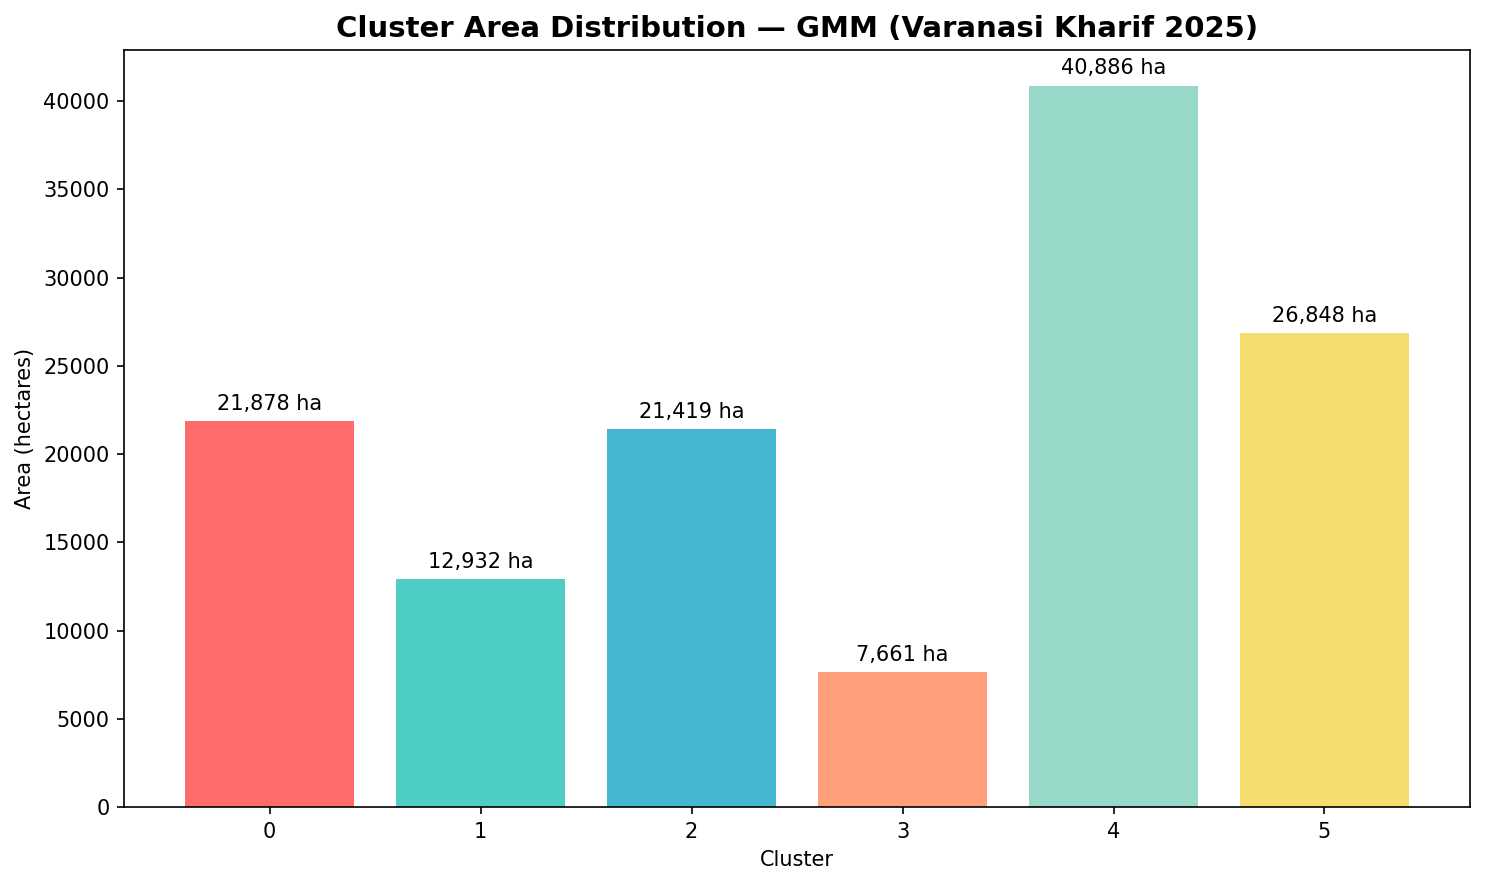

✅ Area chart saved


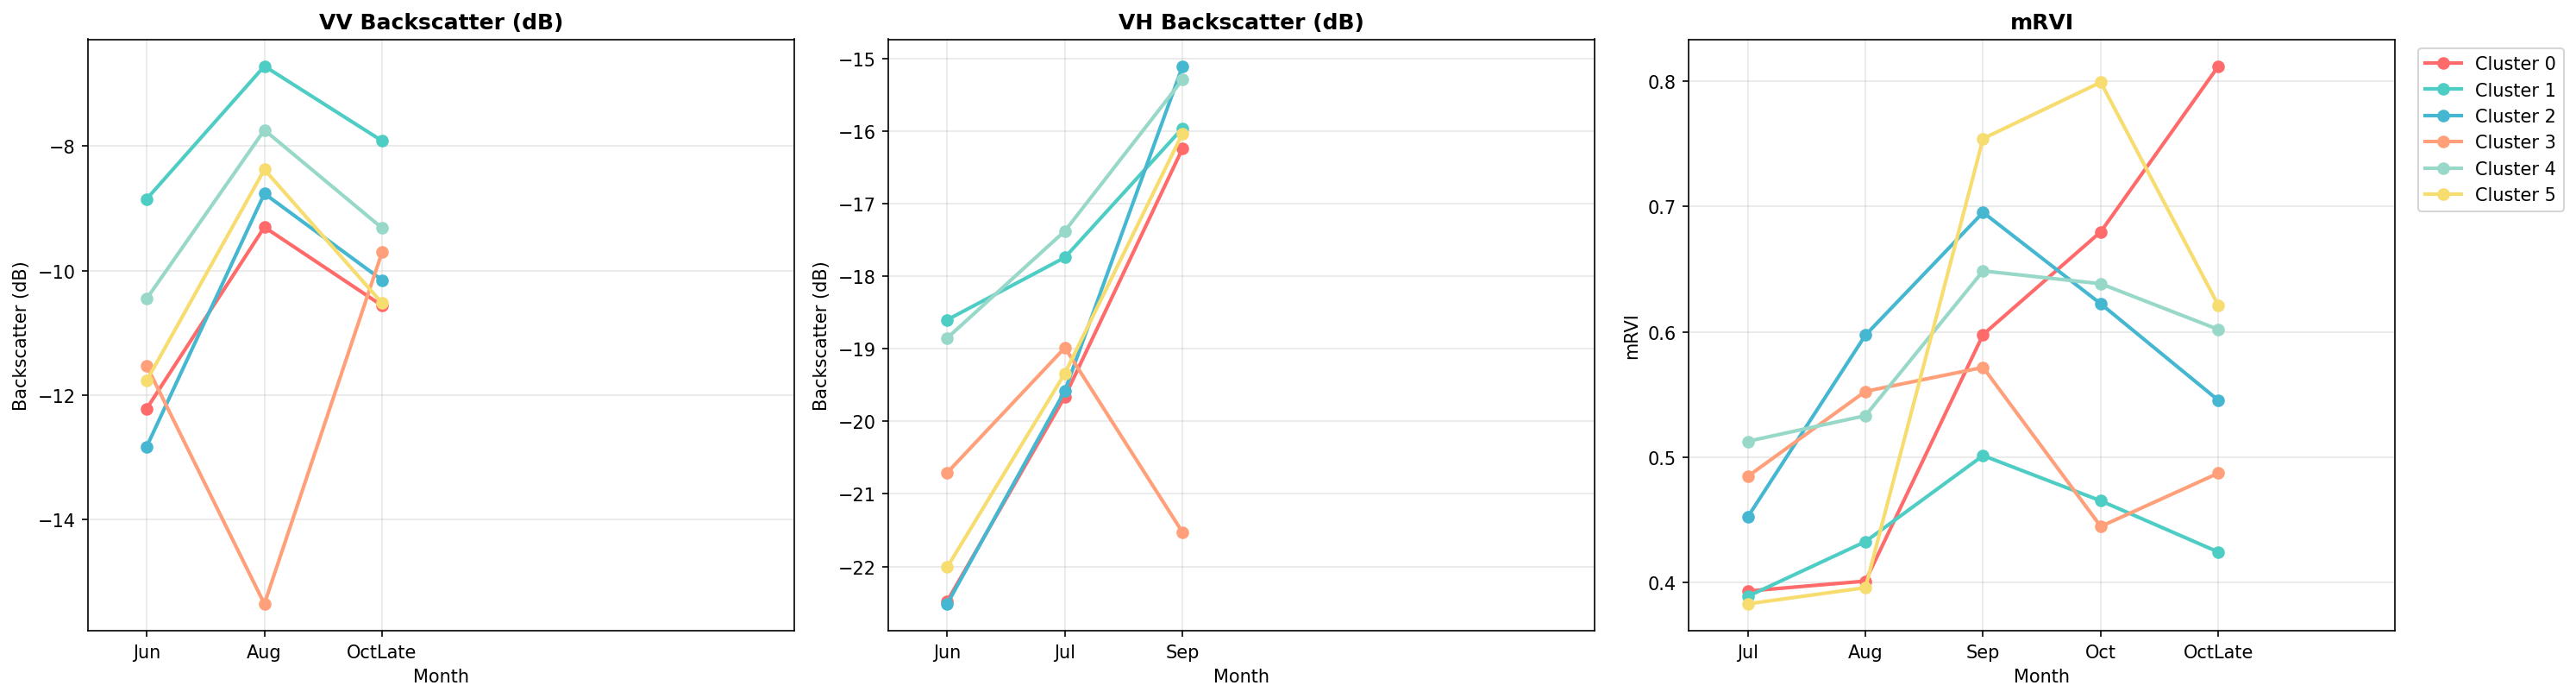

✅ VV/VH/mRVI trend charts saved


In [ ]:
# ============================================================
# CELL 13: Cluster Area Distribution + VV/VH/mRVI Trends
# Kharif 2025 — Varanasi — exact band order from GEE export script
# ============================================================
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw_stack_path = "/content/drive/MyDrive/GEE_Exports/Varanasi_18bands_RAW_Kharif_2025.tif"

# Exact order as stacked in ee.Image.cat([...]) — DO NOT reorder
band_order = [
    ('VV',           'Jun'),
    ('VH',           'Jun'),
    ('VV_VH_diff',   'Jun'),
    ('mRVI',         'Jul'),
    ('VH_VV_ratio',  'Jul'),
    ('VH',           'Jul'),
    ('mRVI',         'Aug'),
    ('VV_VH_diff',   'Aug'),
    ('VV',           'Aug'),
    ('VH',           'Sep'),
    ('VV_VH_diff',   'Sep'),
    ('mRVI',         'Sep'),
    ('mRVI',         'Oct'),
    ('VH_VV_ratio',  'Oct'),
    ('mRVI_stdDev',  'Season'),   # global, not tied to a single month
    ('VV',           'OctLate'),
    ('mRVI',         'OctLate'),
    ('VH_VV_ratio',  'OctLate'),
]

with rasterio.open(raw_stack_path) as src:
    raw_stack = src.read()
    raw_shape = raw_stack.shape[1:]

assert raw_stack.shape[0] == len(band_order), \
    f"Mismatch: file has {raw_stack.shape[0]} bands, band_order has {len(band_order)}"

band_df = pd.DataFrame([
    {'band_idx': i, 'feature': feat, 'month': mo}
    for i, (feat, mo) in enumerate(band_order)
])
print(band_df)

# ---- Verify cluster_map_clean matches raw stack grid ----
assert cluster_map_clean.shape == raw_shape, \
    f"Shape mismatch: cluster_map_clean {cluster_map_clean.shape} vs raw_stack {raw_shape}"

# ---- Extract per-cluster mean for every band ----
records = []
for _, b in band_df.iterrows():
    band_arr = raw_stack[b['band_idx']].astype(np.float32)
    band_arr = np.where(band_arr == 0, np.nan, band_arr)  # adjust if 0 is a valid value for a given feature

    for k in range(optimal_k):
        mask = (cluster_map_clean == k)
        vals = band_arr[mask]
        vals = vals[~np.isnan(vals)]
        if vals.size == 0:
            continue
        records.append({
            'Cluster': k,
            'feature': b['feature'],
            'month': b['month'],
            'value': np.mean(vals)
        })

stats_long = pd.DataFrame(records)

# wide format: Cluster x (feature_month) columns
stats_long['col'] = stats_long['feature'] + '_' + stats_long['month'] + '_mean'
datewise_stats_df = stats_long.pivot(index='Cluster', columns='col', values='value').reset_index()
print(datewise_stats_df)


# ---- Cluster Area Bar Chart ----
pixel_size_m = 20  # NOTE: your export used scale=20, not 10 — update from previous assumption
pixel_area_ha = (pixel_size_m * pixel_size_m) / 10000

cluster_ids = list(range(optimal_k))
cluster_areas_ha = [np.sum(cluster_map_clean == k) * pixel_area_ha for k in cluster_ids]

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
bars = ax.bar(cluster_ids, cluster_areas_ha, color=palette[:optimal_k])
for bar, area in zip(bars, cluster_areas_ha):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(cluster_areas_ha)*0.01,
            f'{area:,.0f} ha', ha='center', va='bottom', fontsize=10)

ax.set_title('Cluster Area Distribution — GMM (Varanasi Kharif 2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Area (hectares)')
ax.set_xticks(cluster_ids)
plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/GEE_Exports/cluster_area_distribution_kharif.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Area chart saved")


# ---- VV / VH / mRVI Raw Value Trends by Cluster ----
month_order_all = ['Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'OctLate']

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), dpi=150)
feature_axes = {'VV': axes[0], 'VH': axes[1], 'mRVI': axes[2]}

for feature, ax in feature_axes.items():
    for k in range(optimal_k):
        row = datewise_stats_df[datewise_stats_df['Cluster'] == k].iloc[0]
        x, y = [], []
        for m in month_order_all:
            col = f'{feature}_{m}_mean'
            if col in row.index and pd.notna(row[col]):
                x.append(m); y.append(row[col])
        if x:
            ax.plot(x, y, marker='o', color=palette[k], label=f'Cluster {k}', linewidth=2)

    ax.set_title(f'{feature}' + (' Backscatter (dB)' if feature != 'mRVI' else ''), fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Backscatter (dB)' if feature != 'mRVI' else 'mRVI')
    ax.set_xlim(-0.5, len(month_order_all) - 0.5)
    ax.grid(True, alpha=0.3)

axes[2].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/GEE_Exports/vv_vh_mrvi_trends_clusters_kharif.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ VV/VH/mRVI trend charts saved")

In [ ]:
# ============================================================
# VISUALIZE EACH PCA BAND SEPARATELY (from existing 8-band tif)
# ============================================================
import rasterio
import numpy as np
import matplotlib.pyplot as plt

tif_path = '/content/drive/MyDrive/GEE_Exports/Varanasi_PCA_8bands_Kharif_2025.tif'

with rasterio.open(tif_path) as src:
    pca_img = src.read()  # shape: (8, height, width)
    n_bands = src.count

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i in range(n_bands):
    band = pca_img[i]
    valid = band[~np.isnan(band)]

    # robust stretch — 2nd/98th percentile so outliers don't wash out the image
    vmin, vmax = np.percentile(valid, [2, 98])

    im = axes[i].imshow(band, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    axes[i].set_title(f'PC{i+1}  (mean={valid.mean():.2f}, std={valid.std():.2f})')
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046)

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/GEE_Exports/PCA_bands_individual.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved individual PCA band visualization")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# NDVI Phenology by Cluster — Kharif 2025 (Varanasi)
# ============================================================
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ndvi_path = "/content/drive/MyDrive/GEE_Exports/Varanasi_NDVI_monthly_Kharif_2025.tif"

# ---- Step 1: Inspect first — confirm band names persisted through export ----
with rasterio.open(ndvi_path) as src:
    print("CRS:", src.crs)
    print("Shape:", src.height, src.width)
    print("Band count:", src.count)
    print("Nodata:", src.nodata)
    print("Descriptions:")
    for i, d in enumerate(src.descriptions, start=1):
        print(f"  Band {i}: {d}")

CRS: EPSG:32644
Shape: 2330 2669
Band count: 6
Nodata: None
Descriptions:
  Band 1: NDVI_Jun
  Band 2: NDVI_Jul
  Band 3: NDVI_Aug
  Band 4: NDVI_Sep
  Band 5: NDVI_Oct
  Band 6: NDVI_OctLate


cluster      0      1      2      3      4      5
month                                            
Jun      0.142  0.275  0.159  0.199  0.285  0.150
Jul      0.147  0.349  0.353  0.225  0.370  0.186
Aug      0.480  0.448  0.496  0.162  0.525  0.561
Sep      0.592  0.500  0.539  0.236  0.579  0.599
Oct      0.740  0.571  0.566  0.347  0.650  0.737
OctLate  0.564  0.422  0.402  0.331  0.492  0.496


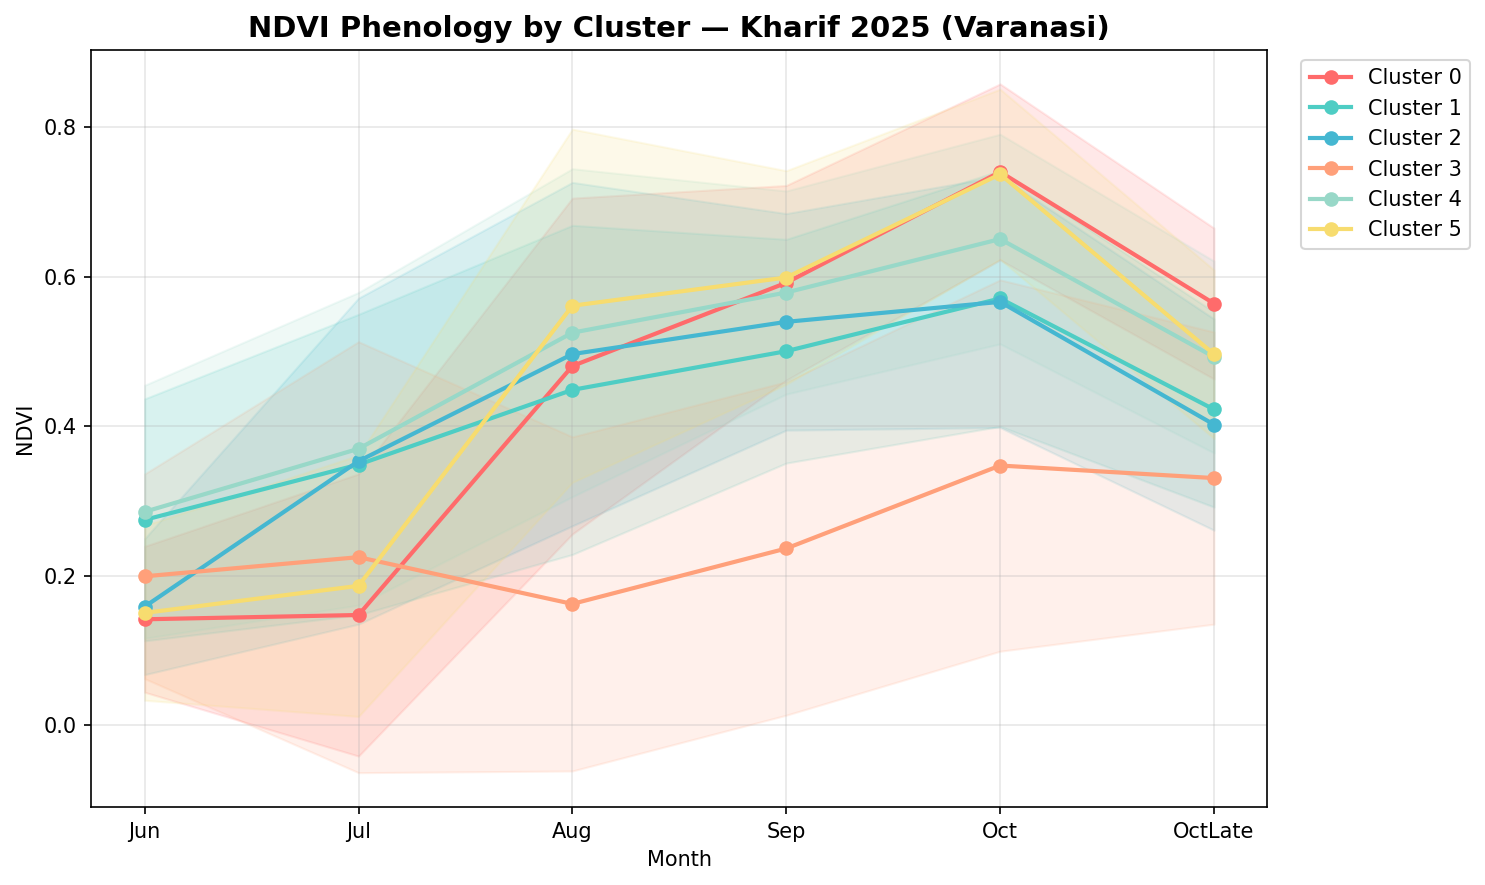

✅ NDVI phenology chart + stats saved


In [ ]:
# ---- Step 2: Extraction + Chart ----

band_month_map = {
    1: "Jun",
    2: "Jul",
    3: "Aug",
    4: "Sep",
    5: "Oct",
    6: "OctLate",
}

n_clusters = optimal_k
month_order = list(band_month_map.values())

palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']

# ---- Reference grid = raw Kharif SAR stack (same grid as cluster_map_clean) ----
raw_stack_path = "/content/drive/MyDrive/GEE_Exports/Varanasi_18bands_RAW_Kharif_2025.tif"
with rasterio.open(raw_stack_path) as ref_src:
    ref_transform = ref_src.transform
    ref_crs = ref_src.crs
    ref_shape = (ref_src.height, ref_src.width)

assert cluster_map_clean.shape == ref_shape, \
    f"cluster_map_clean shape {cluster_map_clean.shape} doesn't match reference raster {ref_shape}"

def align_band_to_reference(band_idx):
    with rasterio.open(ndvi_path) as src:
        dst_arr = np.full(ref_shape, np.nan, dtype=np.float32)
        reproject(
            source=rasterio.band(src, band_idx),
            destination=dst_arr,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.bilinear,
        )
    return dst_arr

# ---- Extract per-cluster NDVI stats per checkpoint ----
records = []
for band_idx, month in band_month_map.items():
    ndvi_arr = align_band_to_reference(band_idx)
    ndvi_arr = np.where((ndvi_arr < -1) | (ndvi_arr > 1), np.nan, ndvi_arr)

    for c in range(n_clusters):
        mask = (cluster_map_clean == c)
        vals = ndvi_arr[mask]
        vals = vals[~np.isnan(vals)]
        if vals.size == 0:
            continue
        records.append({
            "cluster": c,
            "month": month,
            "ndvi_mean": np.mean(vals),
            "ndvi_std": np.std(vals),
            "pixel_count": vals.size
        })

df = pd.DataFrame(records)
df["month"] = pd.Categorical(df["month"], categories=month_order, ordered=True)
df = df.sort_values(["cluster", "month"])

print(df.pivot(index="month", columns="cluster", values="ndvi_mean").round(3))

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

for c in range(n_clusters):
    sub = df[df["cluster"] == c]
    if sub.empty:
        continue
    ax.plot(sub["month"], sub["ndvi_mean"], marker='o', color=palette[c],
            label=f"Cluster {c}", linewidth=2)
    ax.fill_between(sub["month"],
                     sub["ndvi_mean"] - sub["ndvi_std"],
                     sub["ndvi_mean"] + sub["ndvi_std"],
                     color=palette[c], alpha=0.15)

ax.set_title("NDVI Phenology by Cluster — Kharif 2025 (Varanasi)", fontsize=14, fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("NDVI")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/GEE_Exports/ndvi_phenology_clusters_kharif.png', dpi=150, bbox_inches='tight')
plt.show()

#df.to_csv('/content/drive/MyDrive/GEE_Exports/ndvi_cluster_stats_kharif.csv', index=False)
print("✅ NDVI phenology chart + stats saved")

In [ ]:
import os
for f in os.listdir('/content/drive/MyDrive/GEE_Exports'):
    print(f)

Cluster_Centroids_4_JuneNov_Varanasi_with_zScore.gsheet
Cluster_Areas_k5_PCA_Varanasi.gsheet
Cluster_Areas_k5_PCA_Varanasi(using center trainig only).gsheet
Lucknow_18bands.tif
Lucknow_GMM_clusters.tif
Lucknow_GMM_probabilities.tif
Lucknow_clusters_map.png
Lucknow_Fields_to_GMM_Clusters_VALID.csv
Lucknow_Fields_ALL_WithExtentInfo.csv
Varanasi_18bands_2025_26.tif
Varanasi_PCA_8bands_2025_26.tif
BIC_curve.png
kmeans_cluster_signatures.csv
kmeans_mrvi_trajectory.png
kmeans_cluster_areas.csv
Varanasi_18bands_RAW_2025_26.tif
confidence_map.png
confidence_histogram.png
Varanas_Rabi_GMM_clusters.tif
Varanasi_Rabi_GMM_probabilities.tif
varanasi_clusters_map.png
PCA_bands_individual.png
cluster_areas_bar.png
cluster_stats_datewise_raw.csv
mrvi_phenology_clusters.png
Varanasi_NDVI_monthly_2025_26.tif
cluster5_spatial_pattern.png
Varanasi_PCA_8bands_Kharif_2025.tif
Varanasi_18bands_Kharif_2025.tif
Varanasi_18bands_RAW_Kharif_2025.tif
kharif_confidence_map.png
kharif_confidence_histogram.png
Khari

In [ ]:
with rasterio.open(ndvi_path) as src:
    print("Band count:", src.count)
    print("Band descriptions:", src.descriptions)

Band count: 6
Band descriptions: ('NDVI_Jun', 'NDVI_Jul', 'NDVI_Aug', 'NDVI_Sep', 'NDVI_Oct', 'NDVI_OctLate')


In [ ]:
# ============================================================
# REBUILD: derive raw_valid and final_labels_flat from existing arrays
# ============================================================

# Check these still exist as non-array variables
try:
    print("optimal_k:", optimal_k)
except NameError:
    print("optimal_k missing — set manually, e.g. optimal_k = 6")

try:
    print("raw_band_names:", raw_band_names)
except NameError:
    print("raw_band_names missing — need to reload from tif descriptions")

# Flatten raw_stack (18, height, width) -> (n_pixels, 18), apply valid_mask
raw_full = raw_stack.reshape(18, -1).T
raw_valid = raw_full[valid_mask]

# Final cluster labels aligned to valid pixels
final_labels_flat = cluster_map_clean.flatten()[valid_mask]

print(f"\nraw_valid shape: {raw_valid.shape}")
print(f"final_labels_flat shape: {final_labels_flat.shape}")
print(f"X_pca_norm shape: {X_pca_norm.shape}")
print(f"Shapes align: {raw_valid.shape[0] == final_labels_flat.shape[0] == X_pca_norm.shape[0]}")

optimal_k: 6
raw_band_names missing — need to reload from tif descriptions

raw_valid shape: (3326058, 18)
final_labels_flat shape: (3326058,)
X_pca_norm shape: (3326058, 8)
Shapes align: True


In [ ]:
import rasterio

with rasterio.open('/content/drive/MyDrive/GEE_Exports/Varanasi_18bands_RAW_Kharif_2025.tif') as src:
    raw_band_names = list(src.descriptions)

print(raw_band_names)

['VV_Jun', 'VH_Jun', 'VV_VH_diff_Jun', 'mRVI_Jul', 'VH_VV_ratio_Jul', 'VH_Jul', 'mRVI_Aug', 'VV_VH_diff_Aug', 'VV_Aug', 'VH_Sep', 'VV_VH_diff_Sep', 'mRVI_Sep', 'mRVI_Oct', 'VH_VV_ratio_Oct', 'mRVI_stdDev', 'VV_OctLate', 'mRVI_OctLate', 'VH_VV_ratio_OctLate']


In [ ]:
# ============================================================
# CELL 22K: Is Cluster 4 a Mixed-Cropping Condition? (Kharif)
# ============================================================
from scipy import ndimage as ndi
from sklearn.mixture import GaussianMixture

target_cluster = 4
cluster_mask_2d = (cluster_map_clean == target_cluster)

mrvi_cols_ordered = ['mRVI_Jul', 'mRVI_Aug', 'mRVI_Sep', 'mRVI_Oct', 'mRVI_OctLate']

# --- 1. Internal variance check ---
print("="*60)
print("1. WITHIN-CLUSTER VARIANCE (coefficient of variation)")
print("="*60)
cv_summary = []
for k in range(optimal_k):
    mask = final_labels_flat == k
    cluster_data = raw_valid[mask]
    means = np.nanmean(cluster_data, axis=0)
    stds = np.nanstd(cluster_data, axis=0)
    cv = np.nanmean(np.abs(stds / (means + 1e-6)))
    cv_summary.append({'Cluster': k, 'mean_CV': cv, 'n_pixels': mask.sum()})

cv_df = pd.DataFrame(cv_summary)
print(cv_df.to_string(index=False))
print(f"\n→ Cluster {target_cluster} CV: {cv_df.loc[cv_df.Cluster==target_cluster, 'mean_CV'].values[0]:.4f} "
      f"(rank {int(cv_df['mean_CV'].rank(ascending=False)[cv_df.Cluster==target_cluster].values[0])} of {optimal_k}, "
      f"1=most heterogeneous)")

# --- 2. Spatial fragmentation ---
print("\n" + "="*60)
print("2. SPATIAL FRAGMENTATION (patch count & size distribution)")
print("="*60)
frag_summary = []
for k in range(optimal_k):
    binary = (cluster_map_clean == k)
    labeled, n_patches = ndi.label(binary)
    if n_patches == 0:
        continue
    sizes = ndi.sum(binary, labeled, range(1, n_patches + 1))
    frag_summary.append({
        'Cluster': k,
        'n_patches': n_patches,
        'total_pixels': int(binary.sum()),
        'mean_patch_size': np.mean(sizes),
        'median_patch_size': np.median(sizes),
        'pct_patches_lt10px': 100 * (sizes < 10).sum() / n_patches
    })

frag_df = pd.DataFrame(frag_summary)
print(frag_df.to_string(index=False))

# --- 3. Sub-clustering test ---
print("\n" + "="*60)
print("3. SUB-CLUSTERING TEST (does Cluster 4 split into distinct phenologies?)")
print("="*60)
cluster4_mask = final_labels_flat == target_cluster
X_cluster4 = X_pca_norm[cluster4_mask]
raw_cluster4 = raw_valid[cluster4_mask]

for sub_k in [2, 3]:
    sub_gmm = GaussianMixture(n_components=sub_k, covariance_type='full',
                                n_init=5, max_iter=200, random_state=42)
    sub_labels = sub_gmm.fit_predict(X_cluster4)

    print(f"\n--- Sub-K={sub_k} ---")
    unique, counts = np.unique(sub_labels, return_counts=True)
    for u, c in zip(unique, counts):
        sub_mask = sub_labels == u
        sub_data = raw_cluster4[sub_mask]
        mrvi_trend = [np.nanmean(sub_data[:, raw_band_names.index(m)]) for m in mrvi_cols_ordered]
        print(f"  Sub-{u}: {c} pixels ({100*c/len(sub_labels):.1f}%) | "
              f"mRVI Jul→OctLate: {[f'{v:.2f}' for v in mrvi_trend]}")

# --- 4. Visual spatial pattern ---
plt.figure(figsize=(12, 10), dpi=150)
display_map = np.where(cluster_map_clean == target_cluster, 1, np.nan)
plt.imshow(display_map, cmap='YlOrRd')
plt.title(f'Spatial Distribution of Cluster {target_cluster} (Kharif)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'/content/drive/MyDrive/GEE_Exports/kharif_cluster{target_cluster}_spatial_pattern.png', dpi=150)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

SUB-CLUSTERING TEST — Cluster 3

--- Sub-K=2 ---
  Sub-0: 58269 pixels (30.5%) | mRVI Jul→OctLate: ['0.57', '0.62', '0.76', '0.41', '0.45'] | VV Jun/Aug/OctLate: ['-11.76', '-19.99', '-9.99']
  Sub-1: 132662 pixels (69.5%) | mRVI Jul→OctLate: ['0.45', '0.52', '0.49', '0.46', '0.51'] | VV Jun/Aug/OctLate: ['-11.44', '-13.33', '-9.58']

--- Sub-K=3 ---
  Sub-0: 76961 pixels (40.3%) | mRVI Jul→OctLate: ['0.51', '0.62', '0.55', '0.56', '0.58'] | VV Jun/Aug/OctLate: ['-11.96', '-15.51', '-9.70']
  Sub-1: 59361 pixels (31.1%) | mRVI Jul→OctLate: ['0.58', '0.64', '0.77', '0.42', '0.46'] | VV Jun/Aug/OctLate: ['-11.83', '-20.16', '-9.99']
  Sub-2: 54609 pixels (28.6%) | mRVI Jul→OctLate: ['0.35', '0.36', '0.39', '0.31', '0.38'] | VV Jun/Aug/OctLate: ['-10.61', '-9.95', '-9.39']


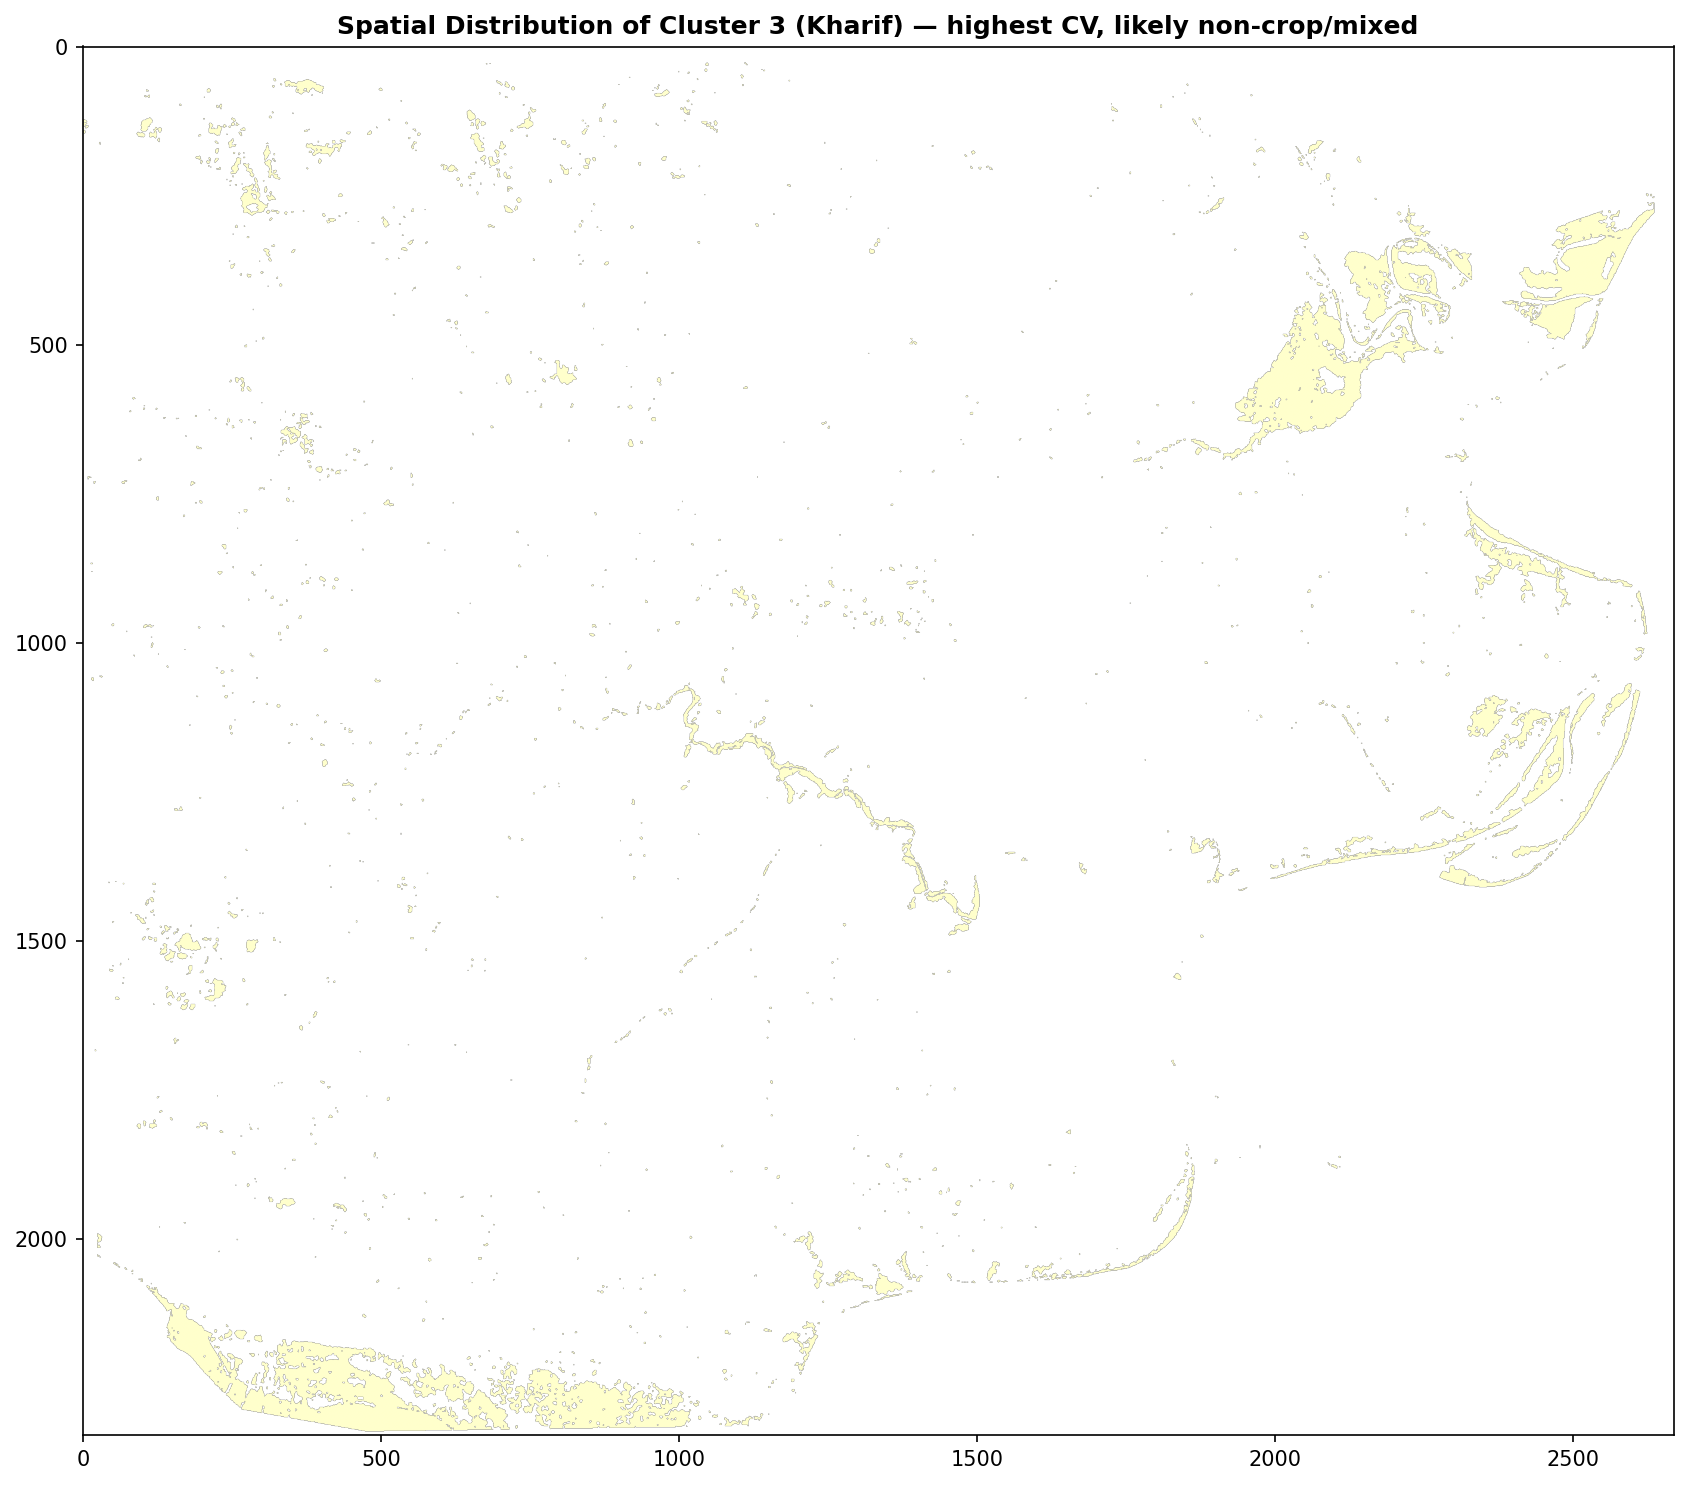


PIXEL COUNT CHECK: is Cluster 3 concentrated near specific features?
Total Cluster 3 pixels: 190931


In [ ]:
# ============================================================
# CELL 22K-B: Diagnostic for Cluster 3 (Kharif) — highest CV, likely non-crop or mixed
# ============================================================
from scipy import ndimage as ndi
from sklearn.mixture import GaussianMixture

target_cluster = 3
mrvi_cols_ordered = ['mRVI_Jul', 'mRVI_Aug', 'mRVI_Sep', 'mRVI_Oct', 'mRVI_OctLate']

# --- Sub-clustering test ---
print("="*60)
print(f"SUB-CLUSTERING TEST — Cluster {target_cluster}")
print("="*60)
cluster3_mask = final_labels_flat == target_cluster
X_cluster3 = X_pca_norm[cluster3_mask]
raw_cluster3 = raw_valid[cluster3_mask]

for sub_k in [2, 3]:
    sub_gmm = GaussianMixture(n_components=sub_k, covariance_type='full',
                                n_init=5, max_iter=200, random_state=42)
    sub_labels = sub_gmm.fit_predict(X_cluster3)

    print(f"\n--- Sub-K={sub_k} ---")
    unique, counts = np.unique(sub_labels, return_counts=True)
    for u, c in zip(unique, counts):
        sub_mask = sub_labels == u
        sub_data = raw_cluster3[sub_mask]
        mrvi_trend = [np.nanmean(sub_data[:, raw_band_names.index(m)]) for m in mrvi_cols_ordered]
        vv_trend = [np.nanmean(sub_data[:, raw_band_names.index(b)])
                    for b in ['VV_Jun', 'VV_Aug', 'VV_OctLate'] if b in raw_band_names]
        print(f"  Sub-{u}: {c} pixels ({100*c/len(sub_labels):.1f}%) | "
              f"mRVI Jul→OctLate: {[f'{v:.2f}' for v in mrvi_trend]} | "
              f"VV Jun/Aug/OctLate: {[f'{v:.2f}' for v in vv_trend]}")

# --- Spatial map ---
plt.figure(figsize=(12, 10), dpi=150)
display_map = np.where(cluster_map_clean == target_cluster, 1, np.nan)
plt.imshow(display_map, cmap='YlOrRd')
plt.title(f'Spatial Distribution of Cluster {target_cluster} (Kharif) — highest CV, likely non-crop/mixed', fontweight='bold')
plt.tight_layout()
#plt.savefig(f'/content/drive/MyDrive/GEE_Exports/kharif_cluster{target_cluster}_spatial_pattern.png', dpi=150)
plt.show()

# --- Where is it relative to water/urban mask? Quick sanity check ---
print("\n" + "="*60)
print("PIXEL COUNT CHECK: is Cluster 3 concentrated near specific features?")
print("="*60)
print(f"Total Cluster {target_cluster} pixels: {cluster3_mask.sum()}")

CV CHECK — Cluster 5
Cluster 5 CV: 0.1749 (rank 5 of 6)

SUB-CLUSTERING TEST — Cluster 5

--- Sub-K=2 ---
  Sub-0: 261910 pixels (39.1%) | mRVI Jul→OctLate: ['0.38', '0.39', '0.76', '0.90', '0.61'] | VV Jun/Aug/OctLate: ['-11.75', '-8.38', '-10.64']
  Sub-1: 408250 pixels (60.9%) | mRVI Jul→OctLate: ['0.38', '0.40', '0.75', '0.74', '0.63'] | VV Jun/Aug/OctLate: ['-11.78', '-8.37', '-10.45']

--- Sub-K=3 ---
  Sub-0: 330531 pixels (49.3%) | mRVI Jul→OctLate: ['0.38', '0.41', '0.74', '0.73', '0.63'] | VV Jun/Aug/OctLate: ['-11.71', '-8.36', '-10.38']
  Sub-1: 177387 pixels (26.5%) | mRVI Jul→OctLate: ['0.40', '0.35', '0.82', '0.83', '0.61'] | VV Jun/Aug/OctLate: ['-12.32', '-8.38', '-10.92']
  Sub-2: 162242 pixels (24.2%) | mRVI Jul→OctLate: ['0.37', '0.42', '0.71', '0.90', '0.62'] | VV Jun/Aug/OctLate: ['-11.29', '-8.40', '-10.39']


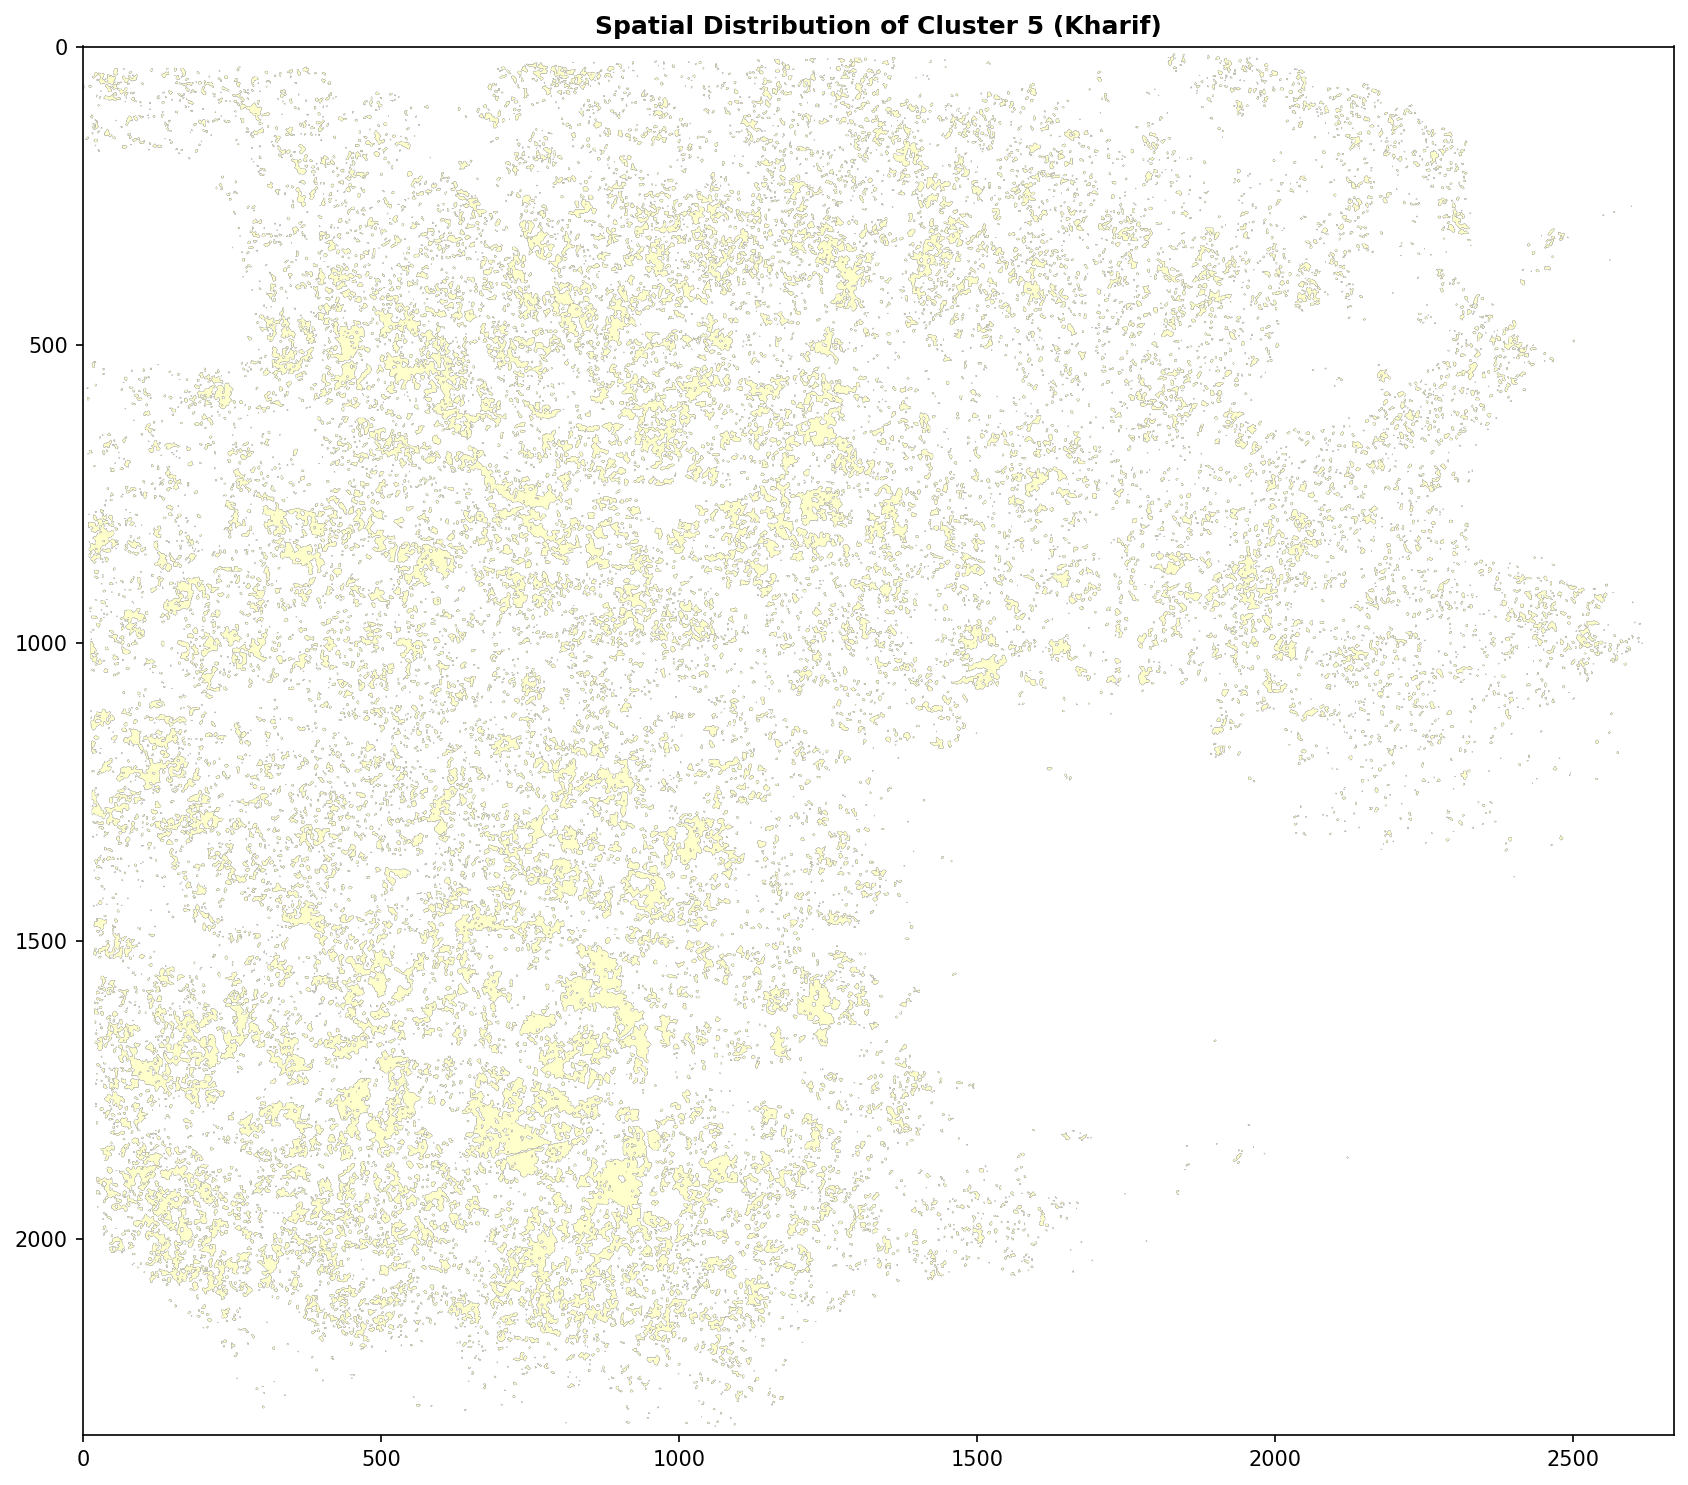

In [ ]:
# ============================================================
# CELL 22K-C: Diagnostic for Cluster 5 (Kharif)
# ============================================================
target_cluster = 5
mrvi_cols_ordered = ['mRVI_Jul', 'mRVI_Aug', 'mRVI_Sep', 'mRVI_Oct', 'mRVI_OctLate']

print("="*60)
print(f"CV CHECK — Cluster {target_cluster}")
print("="*60)
print(f"Cluster {target_cluster} CV: {cv_df.loc[cv_df.Cluster==target_cluster, 'mean_CV'].values[0]:.4f} "
      f"(rank {int(cv_df['mean_CV'].rank(ascending=False)[cv_df.Cluster==target_cluster].values[0])} of {optimal_k})")

print("\n" + "="*60)
print(f"SUB-CLUSTERING TEST — Cluster {target_cluster}")
print("="*60)
cluster5_mask = final_labels_flat == target_cluster
X_cluster5 = X_pca_norm[cluster5_mask]
raw_cluster5 = raw_valid[cluster5_mask]

for sub_k in [2, 3]:
    sub_gmm = GaussianMixture(n_components=sub_k, covariance_type='full',
                                n_init=5, max_iter=200, random_state=42)
    sub_labels = sub_gmm.fit_predict(X_cluster5)

    print(f"\n--- Sub-K={sub_k} ---")
    unique, counts = np.unique(sub_labels, return_counts=True)
    for u, c in zip(unique, counts):
        sub_mask = sub_labels == u
        sub_data = raw_cluster5[sub_mask]
        mrvi_trend = [np.nanmean(sub_data[:, raw_band_names.index(m)]) for m in mrvi_cols_ordered]
        vv_trend = [np.nanmean(sub_data[:, raw_band_names.index(b)])
                    for b in ['VV_Jun', 'VV_Aug', 'VV_OctLate'] if b in raw_band_names]
        print(f"  Sub-{u}: {c} pixels ({100*c/len(sub_labels):.1f}%) | "
              f"mRVI Jul→OctLate: {[f'{v:.2f}' for v in mrvi_trend]} | "
              f"VV Jun/Aug/OctLate: {[f'{v:.2f}' for v in vv_trend]}")

# --- Spatial map ---
plt.figure(figsize=(12, 10), dpi=150)
display_map = np.where(cluster_map_clean == target_cluster, 1, np.nan)
plt.imshow(display_map, cmap='YlOrRd')
plt.title(f'Spatial Distribution of Cluster {target_cluster} (Kharif)', fontweight='bold')
plt.tight_layout()
#plt.savefig(f'/content/drive/MyDrive/GEE_Exports/kharif_cluster{target_cluster}_spatial_pattern.png', dpi=150)
plt.show()

In [ ]:
!pip install fiona --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 28.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Band count: 18
Band descriptions: ('VV_Jun', 'VH_Jun', 'VV_VH_diff_Jun', 'mRVI_Jul', 'VH_VV_ratio_Jul', 'VH_Jul', 'mRVI_Aug', 'VV_VH_diff_Aug', 'VV_Aug', 'VH_Sep', 'VV_VH_diff_Sep', 'mRVI_Sep', 'mRVI_Oct', 'VH_VV_ratio_Oct', 'mRVI_stdDev', 'VV_OctLate', 'mRVI_OctLate', 'VH_VV_ratio_OctLate')
    band_idx      feature    month
0          0           VV      Jun
1          1           VH      Jun
2          2   VV_VH_diff      Jun
3          3         mRVI      Jul
4          4  VH_VV_ratio      Jul
5          5           VH      Jul
6          6         mRVI      Aug
7          7   VV_VH_diff      Aug
8          8           VV      Aug
9          9           VH      Sep
10        10   VV_VH_diff      Sep
11        11         mRVI      Sep
12        12         mRVI      Oct
13        13  VH_VV_ratio      Oct
14        14  mRVI_stdDev   Season
15        15           VV  OctLate
16        16         mRVI  OctLate
17        17  VH_VV_ratio  OctLate
optimal_k inferred as: 6
col  Cluster  VH_

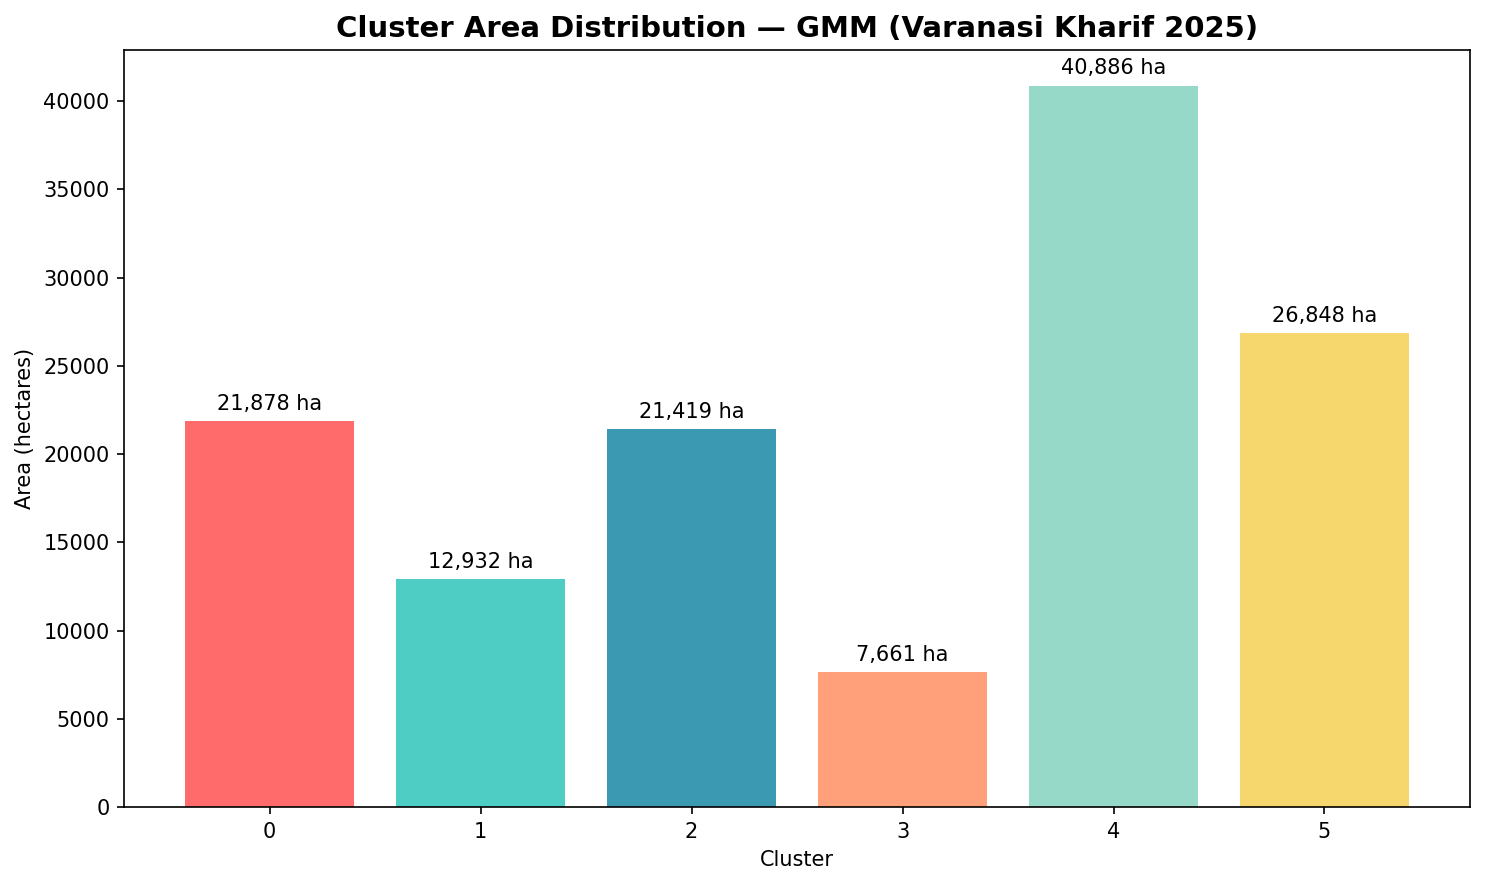

✅ Area chart saved


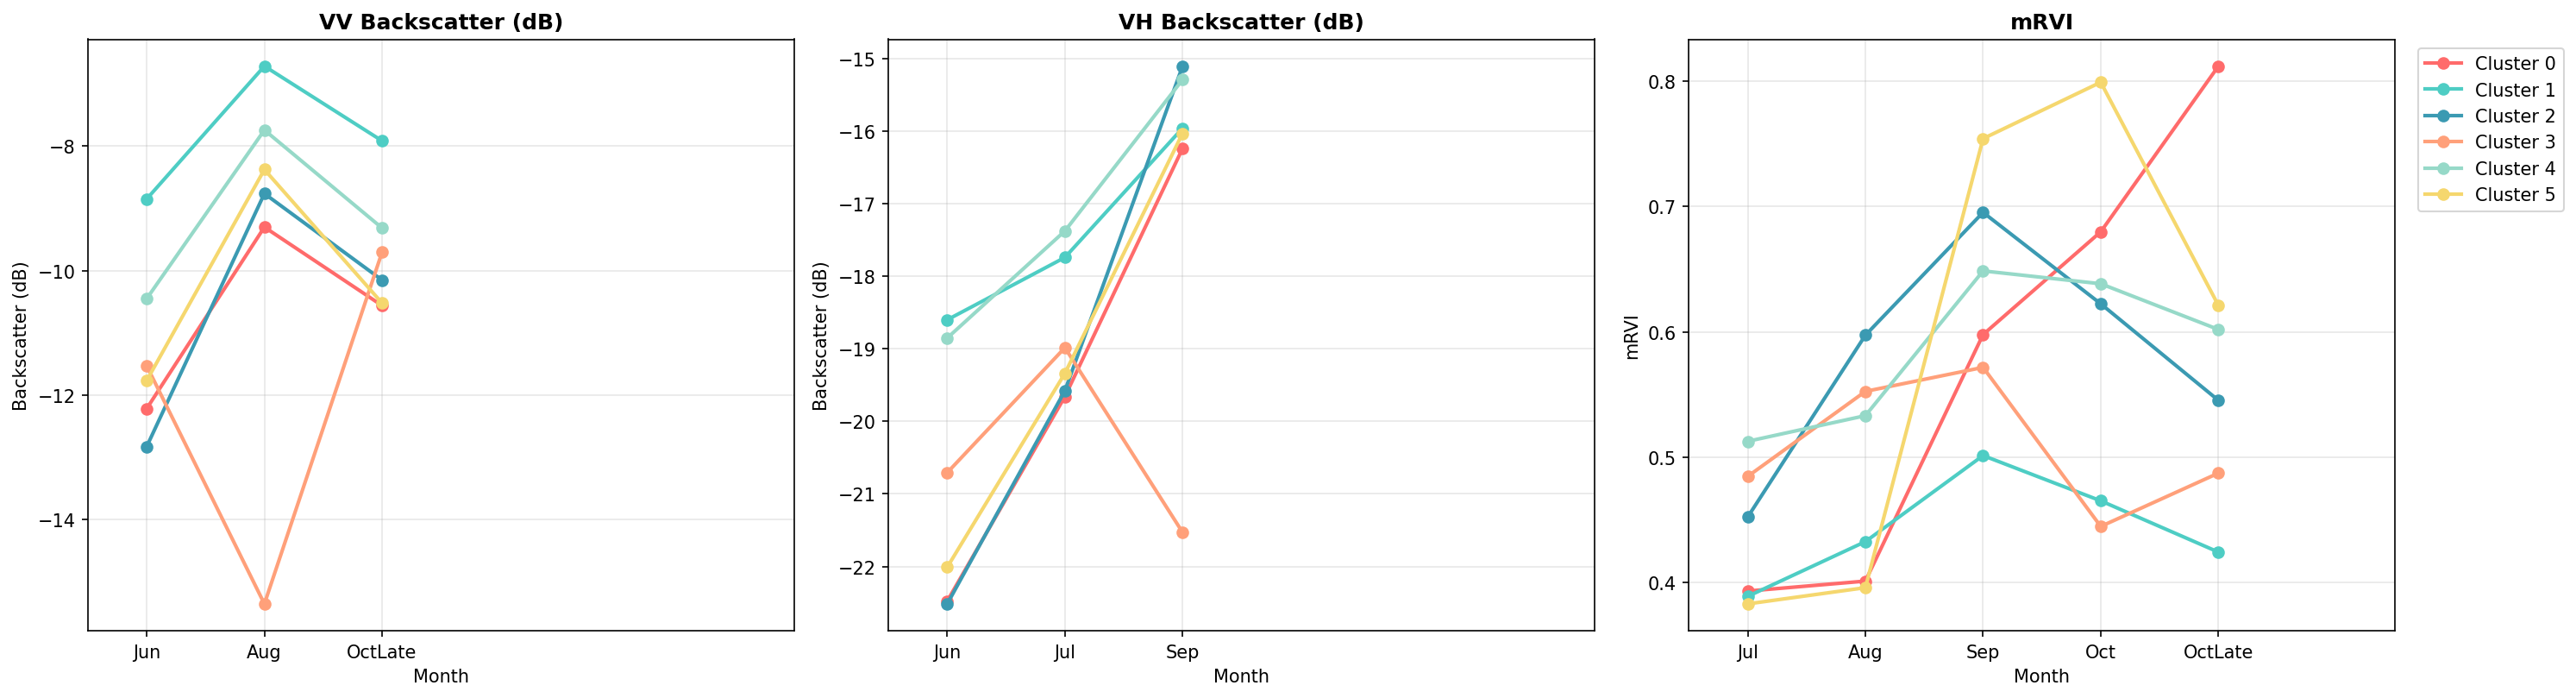

✅ VV/VH/mRVI trend charts saved


In [4]:
# ============================================================
# CELL: Cluster Area Distribution + VV/VH/mRVI Trends
# Kharif 2025 — Varanasi — exact band order from GEE export script
# ============================================================
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw_stack_path = "/content/drive/MyDrive/GEE_Exports/Varanasi_18bands_RAW_Kharif_2025.tif"
cluster_raster_path = "/content/drive/MyDrive/GEE_Exports/Kharif_Varanas_GMM_clusters.tif"

# Exact order as stacked in ee.Image.cat([...]) — DO NOT reorder
band_order = [
    ('VV',           'Jun'),
    ('VH',           'Jun'),
    ('VV_VH_diff',   'Jun'),
    ('mRVI',         'Jul'),
    ('VH_VV_ratio',  'Jul'),
    ('VH',           'Jul'),
    ('mRVI',         'Aug'),
    ('VV_VH_diff',   'Aug'),
    ('VV',           'Aug'),
    ('VH',           'Sep'),
    ('VV_VH_diff',   'Sep'),
    ('mRVI',         'Sep'),
    ('mRVI',         'Oct'),
    ('VH_VV_ratio',  'Oct'),
    ('mRVI_stdDev',  'Season'),   # global, not tied to a single month
    ('VV',           'OctLate'),
    ('mRVI',         'OctLate'),
    ('VH_VV_ratio',  'OctLate'),
]

# ---- STEP 0: Confirm actual band order/descriptions before trusting band_order above ----
with rasterio.open(raw_stack_path) as src:
    print("Band count:", src.count)
    print("Band descriptions:", src.descriptions)

# ---- Load raw 18-band stack ----
with rasterio.open(raw_stack_path) as src:
    raw_stack = src.read()
    raw_shape = raw_stack.shape[1:]

assert raw_stack.shape[0] == len(band_order), \
    f"Mismatch: file has {raw_stack.shape[0]} bands, band_order has {len(band_order)}"

band_df = pd.DataFrame([
    {'band_idx': i, 'feature': feat, 'month': mo}
    for i, (feat, mo) in enumerate(band_order)
])
print(band_df)

# ---- Load cluster raster from disk ----
with rasterio.open(cluster_raster_path) as src:
    cluster_map_clean = src.read(1)

optimal_k = int(np.nanmax(cluster_map_clean)) + 1  # infer K from label range; override manually if needed
print(f"optimal_k inferred as: {optimal_k}")

# ---- Verify cluster raster matches raw stack grid ----
assert cluster_map_clean.shape == raw_shape, \
    f"Shape mismatch: cluster_map_clean {cluster_map_clean.shape} vs raw_stack {raw_shape}"

# ---- Palette ----
palette = ['#FF6B6B', '#4ECDC4', '#3B9AB2', '#FFA07A', '#96D9C8', '#F5D76E']

# ---- Extract per-cluster mean for every band ----
records = []
for _, b in band_df.iterrows():
    band_arr = raw_stack[b['band_idx']].astype(np.float32)
    band_arr = np.where(band_arr == 0, np.nan, band_arr)  # adjust if 0 is a valid value for a given feature

    for k in range(optimal_k):
        mask = (cluster_map_clean == k)
        vals = band_arr[mask]
        vals = vals[~np.isnan(vals)]
        if vals.size == 0:
            continue
        records.append({
            'Cluster': k,
            'feature': b['feature'],
            'month': b['month'],
            'value': np.mean(vals)
        })

stats_long = pd.DataFrame(records)

# wide format: Cluster x (feature_month) columns
stats_long['col'] = stats_long['feature'] + '_' + stats_long['month'] + '_mean'
datewise_stats_df = stats_long.pivot(index='Cluster', columns='col', values='value').reset_index()
print(datewise_stats_df)

# ---- Cluster Area Bar Chart ----
pixel_size_m = 20  # matches export scale=20
pixel_area_ha = (pixel_size_m * pixel_size_m) / 10000

cluster_ids = list(range(optimal_k))
cluster_areas_ha = [np.sum(cluster_map_clean == k) * pixel_area_ha for k in cluster_ids]

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
bars = ax.bar(cluster_ids, cluster_areas_ha, color=palette[:optimal_k])
for bar, area in zip(bars, cluster_areas_ha):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(cluster_areas_ha)*0.01,
            f'{area:,.0f} ha', ha='center', va='bottom', fontsize=10)

ax.set_title('Cluster Area Distribution — GMM (Varanasi Kharif 2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Area (hectares)')
ax.set_xticks(cluster_ids)
plt.tight_layout()
plt.savefig('/content/cluster_area_distribution_kharif.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Area chart saved")

# ---- VV / VH / mRVI Raw Value Trends by Cluster ----
month_order_all = ['Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'OctLate']

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), dpi=150)
feature_axes = {'VV': axes[0], 'VH': axes[1], 'mRVI': axes[2]}

for feature, ax in feature_axes.items():
    for k in range(optimal_k):
        row = datewise_stats_df[datewise_stats_df['Cluster'] == k].iloc[0]
        x, y = [], []
        for m in month_order_all:
            col = f'{feature}_{m}_mean'
            if col in row.index and pd.notna(row[col]):
                x.append(m); y.append(row[col])
        if x:
            ax.plot(x, y, marker='o', color=palette[k], label=f'Cluster {k}', linewidth=2)

    ax.set_title(f'{feature}' + (' Backscatter (dB)' if feature != 'mRVI' else ''), fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Backscatter (dB)' if feature != 'mRVI' else 'mRVI')
    ax.set_xlim(-0.5, len(month_order_all) - 0.5)
    ax.grid(True, alpha=0.3)

axes[2].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('/content/vv_vh_mrvi_trends_clusters_kharif.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ VV/VH/mRVI trend charts saved")